In [1]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.colors import ListedColormap
import numpy as np

# https://www.iucnredlist.org/resources/spatial-data-download

In [2]:
# This is how I created the sample from the opriginal data set

gdf = gpd.read_file("MAMMALS_TERRESTRIAL_ONLY.zip")
gdf.sample(n=500, random_state=42).to_file("MAMMALS_TERRESTRIAL_ONLY_sample.gpkg", driver="GPKG")

/home/thaonguyen/miniforge3/envs/30DayMapChallenge2025/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'MAMMALS_TERRESTRIAL_ONLY.zip': 'MAMMALS_PART1' (default), 'MAMMALS_PART2'. Specify layer parameter to avoid this warning.
  result = read_func(


In [3]:
file = "MAMMALS_TERRESTRIAL_ONLY.zip"
sample = "MAMMALS_TERRESTRIAL_ONLY_sample.gpkg"

print('Make sure to adjust the file name between sample and full data set')
gdf = gpd.read_file(file if os.path.exists(file) else sample)
print(gdf.crs)
print(len(gdf))
gdf.head()

Make sure to adjust the file name between sample and full data set


/home/thaonguyen/miniforge3/envs/30DayMapChallenge2025/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'MAMMALS_TERRESTRIAL_ONLY.zip': 'MAMMALS_PART1' (default), 'MAMMALS_PART2'. Specify layer parameter to avoid this warning.
  result = read_func(


EPSG:4326
6619


,id_no,sci_name,presence,origin,seasonal,compiler,yrcompiled,citation,subspecies,subpop,...,order_,family,genus,category,marine,terrestria,freshwater,SHAPE_Leng,SHAPE_Area,geometry
0,18,Abrocoma boliviensis,1,1,1,IUCN SSC Small Mammal Specialist Group,2016,IUCN SSC Small Mammal Specialist Group,NaN,NaN,...,RODENTIA,ABROCOMIDAE,Abrocoma,CR,false,true,false,0.305150,0.005520,"POLYGON ((-64.46864 -17.88625, -64.45733 -17.8..."
1,138,Acerodon humilis,1,1,1,IUCN,2008,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,EN,false,true,false,2.251406,0.075689,"MULTIPOLYGON (((126.6535 3.98854, 126.657 3.98..."
2,139,Acerodon jubatus,1,1,1,IUCN,2008,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,EN,false,true,false,1.441266,0.075349,"POLYGON ((121.882 13.55314, 121.8853 13.55214,..."
3,139,Acerodon jubatus,1,1,1,IUCN,2008,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,EN,false,true,false,7.857902,1.275175,"POLYGON ((119.8844 16.39114, 119.8895 16.38844..."
4,139,Acerodon jubatus,1,1,1,IUCN,2008,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,EN,false,true,false,2.683004,0.068227,"MULTIPOLYGON (((125.6449 9.87744, 125.6492 9.8..."


<Axes: >

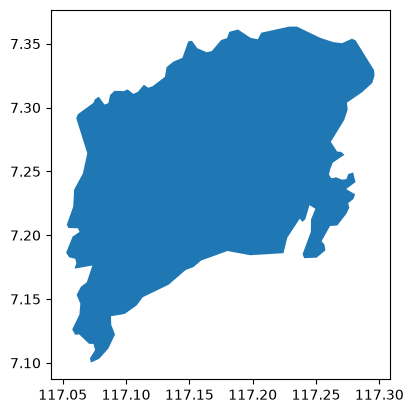

In [8]:
gdf.sample(1).plot()

<Axes: >

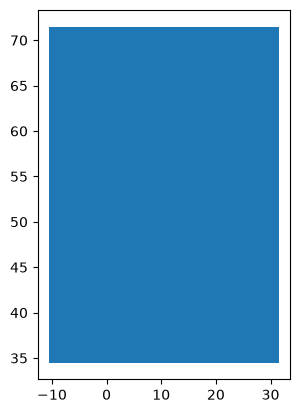

In [9]:
europe_bbox = (-10.5, 34.5, 31.5, 71.5)
minx, miny, maxx, maxy = europe_bbox
bbox_gdf = gpd.GeoDataFrame(geometry=[box(minx, miny, maxx, maxy)], crs="EPSG:4326")
bbox_gdf.plot()

In [10]:
gdf_europe = gpd.clip(gdf, bbox_gdf)
len(gdf_europe)

363

<Axes: >

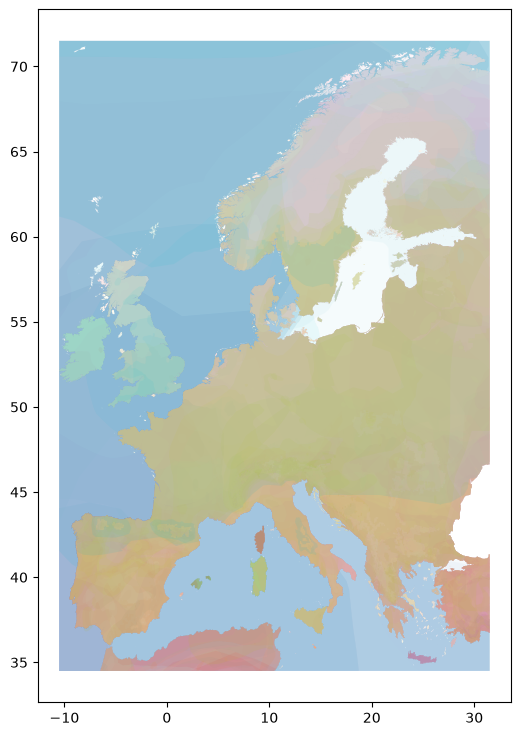

In [12]:
f, ax = plt.subplots(1,1,figsize=(14,9))

gdf_europe.plot(cmap = 'tab20', alpha = 0.1, linewidth = 2, ax = ax)

#Save fig



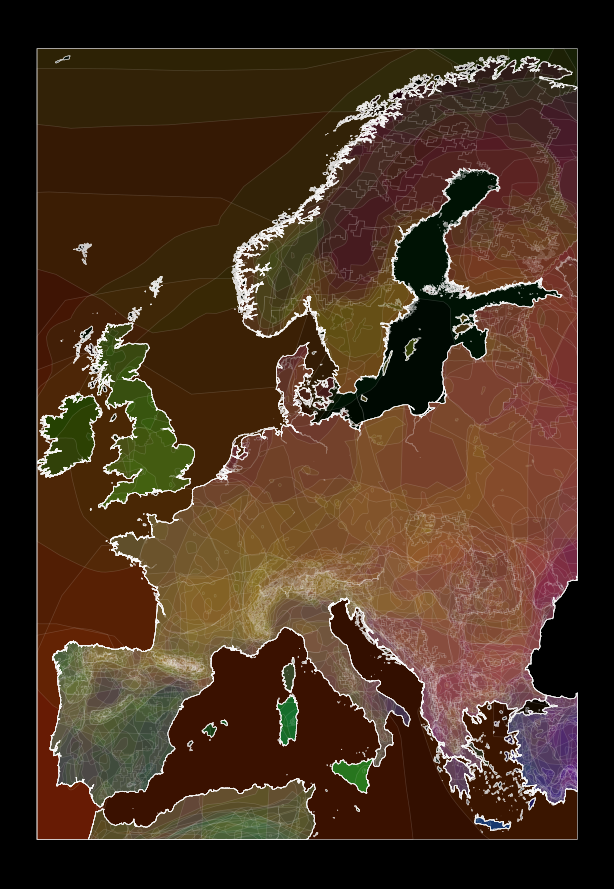

In [13]:
fig, ax = plt.subplots(figsize=(14, 9), facecolor="black")

colors = plt.cm.hsv(np.linspace(0, 1, 256)) 
neon_cmap = ListedColormap(colors)

gdf_europe.plot(
    ax=ax,
    cmap = neon_cmap,
    alpha=0.04,             
    linewidth=0.0)


gdf_europe.plot(
    ax=ax,
    facecolor='none',    
    edgecolor='white',  
    alpha=0.15,      
    linewidth=0.5         
)


ax.set_axis_off()
ax.set_facecolor("black")
fig.patch.set_facecolor("black")

plt.tight_layout()
plt.savefig('DAY2_full.png', bbox_inches = 'tight', dpi = 300)
plt.show()

In [1]:
import geopandas as gpd
import folium
import numpy as np
from matplotlib import cm, colors

m = folium.Map(
    location=[54, 15], 
    zoom_start=4,
    tiles="CartoDB dark_matter"
)

neon_cmap = plt.get_cmap('hsv', 256)
norm = colors.Normalize(vmin=0, vmax=len(gdf_europe))


for i, (_, row) in enumerate(gdf_europe.iterrows()):
    color = colors.to_hex(neon_cmap(norm(i)))
    tooltip_text = (
        f"<b>{row['sci_name']}</b><br>"
        f"ID: {row['id_no']}<br>"
        f"Family: {row['family']}<br>"
        f"Order: {row['order_']}<br>"
        f"Category: {row['category']}"
    )

    folium.GeoJson(
        data=row["geometry"].__geo_interface__,
        style_function=lambda feature, color=color: {
            "fill": False,
            "color": color,
            "weight": 0.5,
            "opacity": 0.3
        },
        tooltip=folium.Tooltip(tooltip_text, sticky=True)
    ).add_to(m)

m.save("europe_mammals_neon.html")
m

NameError: name 'plt' is not defined